#  Task-01: Population Distribution Analysis

### Prodigy InfoTech – Data Science Internship

---

### Objective

Create a histogram and bar chart to visualize the distribution of population
across countries using World Bank population data ***continent wise***.

### Dataset

**World Bank – Total Population by Country**

**Analysis Matrix:** Continent wise

### Tools Used

- Python
- Pandas
- Matplotlib
- Seaborn


---


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


Loaded the dataset and skipped first four rows as they contain metadata.

In [3]:
file_path = r"C:\Users\Admin\Desktop\tasks\task 1\API_SP.POP.TOTL_DS2_en_csv_v2_38144.csv"
df = pd.read_csv(file_path, skiprows=4)
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


EDA

In [4]:
df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107624.0,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750503764.0,769294618.0,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,NaN
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,429454743.0,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,521764076.0,NaN
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,29183070.0,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0,NaN


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 266
Columns: 70


In [6]:
print(df.columns.tolist())

['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', 'Unnamed: 69']


## Understand the data 

As you can see, the dataset has the population data and other geographical entities data across multiple years. 
For this project, we are considering ***Continent wise distribution of population for the year 2024*** to visualize how population is disributed across the countires. 

In [7]:
df.isnull().sum().sort_values(ascending=False).head(10)

Unnamed: 69    266
1960             2
1963             2
1964             2
1962             2
1961             2
1978             2
1979             2
1980             2
1981             2
dtype: int64

## Created a country-level dataset

In [8]:
country_df = df[
    df["Country Code"].str.len() == 3
].copy()
country_df = country_df.dropna(subset=["2024"])
country_df[["Country Name", "Country Code", "2024"]].head()

,Country Name,Country Code,2024
0,Aruba,ABW,107624.0
1,Africa Eastern and Southern,AFE,769294618.0
2,Afghanistan,AFG,42647492.0
3,Africa Western and Central,AFW,521764076.0
4,Angola,AGO,37885849.0


In [9]:
country_df["Population"] = country_df["2024"]
country_df[["Country Name", "Population"]].head()

,Country Name,Population
0,Aruba,107624.0
1,Africa Eastern and Southern,769294618.0
2,Afghanistan,42647492.0
3,Africa Western and Central,521764076.0
4,Angola,37885849.0


Removing Aggregates and keeping the data relevant to the ***countries*** only

In [10]:
aggregate_codes = [
    "AFE", "AFW", "ARB", "CSS", "CEB", "EAR", "EAS",
    "EAP", "TEA", "EMU", "ECS", "TEC", "EUU", "FCS",
    "HPC", "IBT", "IBD", "IBL", "IDX", "IDA", "IDB",
    "IDN", "IDX", "LAC", "LDC", "LIC", "LMC", "LMY",
    "LTE", "MEA", "MIC", "MNA", "NAC", "OED", "OSS",
    "PSS", "PST", "PRE", "SAS", "SSA", "SSF", "SST",
    "UMC", "WLD"
]
country_df = country_df[
    ~country_df["Country Code"].isin(aggregate_codes)
].copy()
print("Number of country-level records:", len(country_df))

Number of country-level records: 223


##  Data Cleaning

The dataset includes both individual countries and regional/income-group
aggregates.

To ensure that the visualization represents **country-level population
distribution**, aggregate records were excluded from the analysis.

Records with missing 2024 population values were also removed.

In [11]:
country_df[["Country Name", "Population"]].head(10)

,Country Name,Population
0,Aruba,107624.0
2,Afghanistan,42647492.0
4,Angola,37885849.0
5,Albania,2714617.0
6,Andorra,81938.0
8,United Arab Emirates,10876981.0
9,Argentina,45696159.0
10,Armenia,3033500.0
11,American Samoa,46765.0
12,Antigua and Barbuda,93772.0


In [12]:
country_df[["Country Name", "Population"]].head(10)

,Country Name,Population
0,Aruba,107624.0
2,Afghanistan,42647492.0
4,Angola,37885849.0
5,Albania,2714617.0
6,Andorra,81938.0
8,United Arab Emirates,10876981.0
9,Argentina,45696159.0
10,Armenia,3033500.0
11,American Samoa,46765.0
12,Antigua and Barbuda,93772.0


##  Descriptive Statistics

Before creating the visualizations, we examine basic statistics of the
population data.

In [13]:
country_df["Population"].describe()

count    2.230000e+02
mean     6.510111e+07
std      2.289594e+08
min      9.646000e+03
25%      8.977060e+05
50%      7.224614e+06
75%      3.079264e+07
max      1.677385e+09
Name: Population, dtype: float64

##  Population Distribution by Continent (2024)

### Why analyze continents?

The World Bank dataset contains population data for individual countries across multiple years.  
To better understand the **categorical distribution** of the world's population, countries are grouped into their respective continents.

This visualization answers the question:

> **How is the global population distributed across continents in 2024?**

### What this chart shows

- **Categorical variable:** Continent
- **Numerical variable:** Total population
- **Year selected:** 2024
- **Visualization:** Bar Chart

By aggregating country populations at the continental level, the chart provides a clearer comparison of where the world's population is concentrated.

In [14]:
continent_map = {
    # Africa
    "DZA": "Africa", "AGO": "Africa", "BEN": "Africa", "BWA": "Africa",
    "BFA": "Africa", "BDI": "Africa", "CPV": "Africa", "CMR": "Africa",
    "CAF": "Africa", "TCD": "Africa", "COM": "Africa", "COG": "Africa",
    "COD": "Africa", "CIV": "Africa", "DJI": "Africa", "EGY": "Africa",
    "GNQ": "Africa", "ERI": "Africa", "SWZ": "Africa", "ETH": "Africa",
    "GAB": "Africa", "GMB": "Africa", "GHA": "Africa", "GIN": "Africa",
    "GNB": "Africa", "KEN": "Africa", "LSO": "Africa", "LBR": "Africa",
    "LBY": "Africa", "MDG": "Africa", "MWI": "Africa", "MLI": "Africa",
    "MRT": "Africa", "MUS": "Africa", "MAR": "Africa", "MOZ": "Africa",
    "NAM": "Africa", "NER": "Africa", "NGA": "Africa", "RWA": "Africa",
    "STP": "Africa", "SEN": "Africa", "SYC": "Africa", "SLE": "Africa",
    "SOM": "Africa", "ZAF": "Africa", "SSD": "Africa", "SDN": "Africa",
    "TZA": "Africa", "TGO": "Africa", "TUN": "Africa", "UGA": "Africa",
    "ZMB": "Africa", "ZWE": "Africa",

    # Asia
    "AFG": "Asia", "ARM": "Asia", "AZE": "Asia", "BHR": "Asia",
    "BGD": "Asia", "BTN": "Asia", "BRN": "Asia", "KHM": "Asia",
    "CHN": "Asia", "CYP": "Asia", "GEO": "Asia", "IND": "Asia",
    "IDN": "Asia", "IRN": "Asia", "IRQ": "Asia", "ISR": "Asia",
    "JPN": "Asia", "JOR": "Asia", "KAZ": "Asia", "KWT": "Asia",
    "KGZ": "Asia", "LAO": "Asia", "LBN": "Asia", "MYS": "Asia",
    "MDV": "Asia", "MNG": "Asia", "MMR": "Asia", "NPL": "Asia",
    "OMN": "Asia", "PAK": "Asia", "PHL": "Asia", "QAT": "Asia",
    "SAU": "Asia", "SGP": "Asia", "KOR": "Asia", "LKA": "Asia",
    "SYR": "Asia", "TJK": "Asia", "THA": "Asia", "TLS": "Asia",
    "TUR": "Asia", "TKM": "Asia", "ARE": "Asia", "UZB": "Asia",
    "VNM": "Asia", "YEM": "Asia",

    # Europe
    "ALB": "Europe", "AND": "Europe", "AUT": "Europe", "BLR": "Europe",
    "BEL": "Europe", "BIH": "Europe", "BGR": "Europe", "HRV": "Europe",
    "CZE": "Europe", "DNK": "Europe", "EST": "Europe", "FIN": "Europe",
    "FRA": "Europe", "DEU": "Europe", "GRC": "Europe", "HUN": "Europe",
    "ISL": "Europe", "IRL": "Europe", "ITA": "Europe", "LVA": "Europe",
    "LIE": "Europe", "LTU": "Europe", "LUX": "Europe", "MLT": "Europe",
    "MDA": "Europe", "MCO": "Europe", "MNE": "Europe", "NLD": "Europe",
    "MKD": "Europe", "NOR": "Europe", "POL": "Europe", "PRT": "Europe",
    "ROU": "Europe", "RUS": "Europe", "SMR": "Europe", "SRB": "Europe",
    "SVK": "Europe", "SVN": "Europe", "ESP": "Europe", "SWE": "Europe",
    "CHE": "Europe", "UKR": "Europe", "GBR": "Europe", "VAT": "Europe",

    # North America
    "CAN": "North America", "USA": "North America", "MEX": "North America",
    "GTM": "North America", "BLZ": "North America", "CRI": "North America",
    "SLV": "North America", "HND": "North America", "NIC": "North America",
    "PAN": "North America", "CUB": "North America", "HTI": "North America",
    "DOM": "North America", "JAM": "North America", "BHS": "North America",
    "BRB": "North America", "ATG": "North America", "DMA": "North America",
    "GRD": "North America", "KNA": "North America", "LCA": "North America",
    "VCT": "North America", "TTO": "North America",

    # South America
    "ARG": "South America", "BOL": "South America", "BRA": "South America",
    "CHL": "South America", "COL": "South America", "ECU": "South America",
    "GUY": "South America", "PRY": "South America", "PER": "South America",
    "SUR": "South America", "URY": "South America", "VEN": "South America",

    # Oceania
    "AUS": "Oceania", "FJI": "Oceania", "KIR": "Oceania",
    "MHL": "Oceania", "FSM": "Oceania", "NRU": "Oceania",
    "NZL": "Oceania", "PLW": "Oceania", "PNG": "Oceania",
    "WSM": "Oceania", "SLB": "Oceania", "TON": "Oceania",
    "TUV": "Oceania", "VUT": "Oceania"
}

In [15]:
country_df["Continent"] = country_df["Country Code"].map(continent_map)

In [16]:
country_df[country_df["Continent"].isna()][
    ["Country Name", "Country Code"]
]

,Country Name,Country Code
0,Aruba,ABW
11,American Samoa,ASM
27,Bermuda,BMU
38,Channel Islands,CHI
51,Curacao,CUW
52,Cayman Islands,CYM
64,Europe & Central Asia (excluding high income),ECA
78,Faroe Islands,FRO
84,Gibraltar,GIB
91,Greenland,GRL


In [17]:
country_df["Continent"].value_counts()

Continent
Africa           54
Asia             45
Europe           43
North America    23
Oceania          14
South America    12
Name: count, dtype: int64

In [18]:
country_df[country_df["Continent"].isna()][
    ["Country Name", "Country Code"]
]

,Country Name,Country Code
0,Aruba,ABW
11,American Samoa,ASM
27,Bermuda,BMU
38,Channel Islands,CHI
51,Curacao,CUW
52,Cayman Islands,CYM
64,Europe & Central Asia (excluding high income),ECA
78,Faroe Islands,FRO
84,Gibraltar,GIB
91,Greenland,GRL


In [19]:
country_df["Continent"].value_counts()

Continent
Africa           54
Asia             45
Europe           43
North America    23
Oceania          14
South America    12
Name: count, dtype: int64

In [20]:
country_df[country_df["Continent"].isna()][
    ["Country Name", "Country Code"]
]

,Country Name,Country Code
0,Aruba,ABW
11,American Samoa,ASM
27,Bermuda,BMU
38,Channel Islands,CHI
51,Curacao,CUW
52,Cayman Islands,CYM
64,Europe & Central Asia (excluding high income),ECA
78,Faroe Islands,FRO
84,Gibraltar,GIB
91,Greenland,GRL


In [21]:
country_df["Continent"].value_counts()

Continent
Africa           54
Asia             45
Europe           43
North America    23
Oceania          14
South America    12
Name: count, dtype: int64

## Calculated population by continent 

In [22]:
continent_population = (
    country_df
    .groupby("Continent")["Population"]
    .sum()
    .sort_values(ascending=False)
)

continent_population

Continent
Asia             4.448523e+09
Africa           1.513319e+09
Europe           7.410580e+08
North America    6.044851e+08
South America    4.352993e+08
Oceania          4.584228e+07
Name: Population, dtype: float64

## Converted them into billions 

In [23]:
continent_population_billion = (
    continent_population / 1_000_000_000
)

continent_population_billion

Continent
Asia             4.448523
Africa           1.513319
Europe           0.741058
North America    0.604485
South America    0.435299
Oceania          0.045842
Name: Population, dtype: float64

## Created the chart

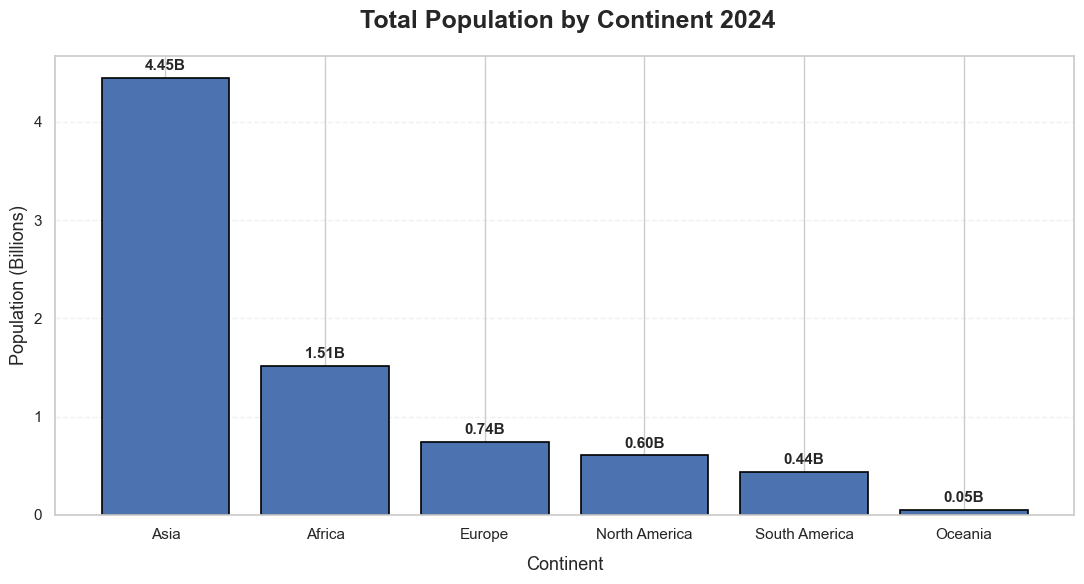

In [24]:
plt.figure(figsize=(11, 6))

bars = plt.bar(
    continent_population_billion.index,
    continent_population_billion.values,
    edgecolor="black",
    linewidth=1.2
)

plt.title(
    " Total Population by Continent 2024",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Continent",
    fontsize=13,
    labelpad=10
)

plt.ylabel(
    "Population (Billions)",
    fontsize=13
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.05,
        f"{height:.2f}B",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

###  Interpretation

The chart shows a significant difference in population across continents in
2024.

- **Asia** has the largest population among all continents.
- **Africa** has the second-largest population and represents a substantial
  share of the world's population.
- **Europe, North America, and South America** have considerably smaller
  populations compared with Asia and Africa.
- **Oceania** has the smallest population among the six continents.

Overall, the visualization demonstrates that the global population is
unevenly distributed across continents, with Asia accounting for the largest
share.

In [25]:
country_count = (
    country_df["Continent"]
    .value_counts()
    .sort_values(ascending=False)
)

country_count

Continent
Africa           54
Asia             45
Europe           43
North America    23
Oceania          14
South America    12
Name: count, dtype: int64

### Extra Analysis- Visualization of Continent wise counties.

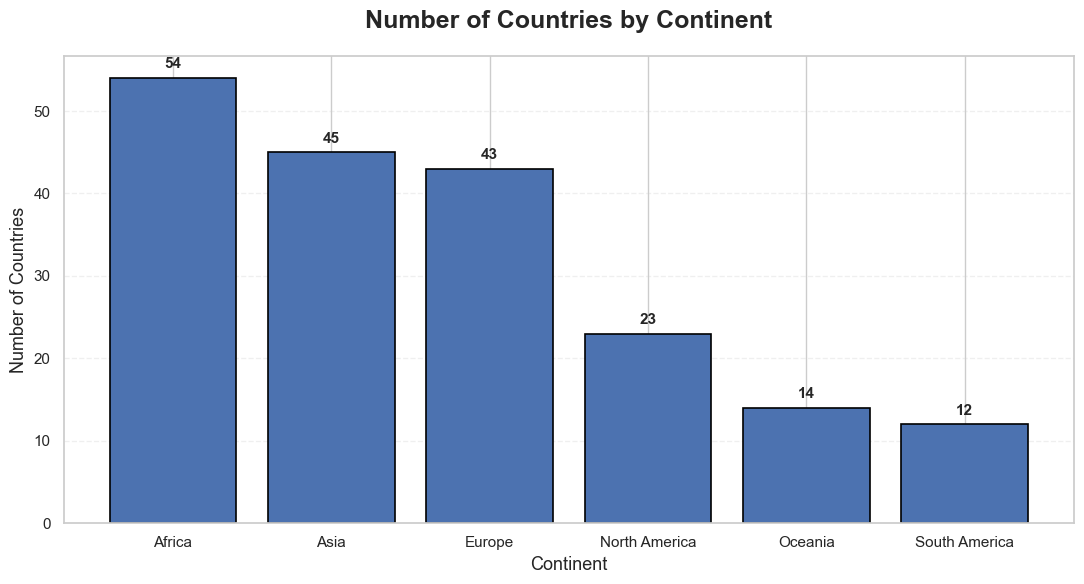

In [26]:
plt.figure(figsize=(11, 6))

bars = plt.bar(
    country_count.index,
    country_count.values,
    edgecolor="black",
    linewidth=1.2
)

plt.title(
    "Number of Countries by Continent",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel("Continent", fontsize=13)
plt.ylabel("Number of Countries", fontsize=13)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### Interpretation 

As the the extra analysis its clear that the Africa has most amount of countries. 
Which suggests that ***number of country!=number of population*** in a continent 


##  Conclusion

The analysis shows that population is highly unevenly distributed across countries and continents. The population distribution is strongly right-skewed, with most countries having relatively smaller populations and only a few countries having very large populations.

By grouping countries by continent, the analysis provides a clearer understanding of how population sizes vary across different regions of the world. Asia contains several of the world's most populous countries, resulting in a concentration of larger population values, while many countries in other continents have comparatively smaller populations.

The bar graph effectively visualizes the distribution of the continuous variable **country population** while the continental grouping provides additional context for comparing population patterns. Overall, the visualization demonstrates how statistical plots can be used to identify patterns, differences, and skewness within population data.